In [1]:
pip install yellowbrick

Note: you may need to restart the kernel to use updated packages.


In [107]:
pip install xgboost

  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/24/ec/ad387100fa3cc2b9b81af0829b5ecfe75ec5bb19dd7c19d4fea06fb81802/xgboost-2.0.3-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/99.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/99.8 MB 640.0 kB/s eta 0:02:36
   ---------------------------------------- 0.1/99.8 MB 1.2 MB/s eta 0:01:25
   ---------------------------------------- 0.6/99.8 MB 4.3 MB/s eta 0:00:23
   ---------------------------------------- 1.0/99.8 MB 5.8 MB/s eta 0:00:18
    --------------------------------------- 1.6/99.8 MB 7.1 MB/s eta 0:00:14
    --------------------------------------- 2.2/99.8 MB 8.4 MB/s eta 0:00:12
   - -------------------------------------- 2.9/99.8 MB 9.7 MB/s eta 0:00:11
   - -------------------------------------- 3.4/99.8 MB 9.4 MB/s eta 0:00:11
   - -------------------------------------- 4.3/99.8 MB 10.5 MB/s eta 0:00:10
   -- -----------------------

In [ ]:
# MAJ du package threadpoolctl, il empêchait l'exécution de la méthode du coude pour capter le nombre de clusters idéal pour le kmeans
pip install threadpoolctl==3.1.0

In [1]:
# Intégration des librairies
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline
import pylab
# Utile pour mettre sous forme d'un tableau clair les données
from tabulate import tabulate

# Graphique 3D dynamique 
import plotly.express as px

# Utile pour la normalisation des données avec le standard scaler
from sklearn.preprocessing import StandardScaler

# Utile pour faire la répartition des données pour le modèle, entre test et entrainement
from sklearn.model_selection import train_test_split

# Régression logistique avec Scikit learn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
    # Utile pour mettre en place le test de validation AUC-ROC
from sklearn.metrics import roc_auc_score
    # Utile pour mettre en place le test de validation de la matrice de confusion
from sklearn.metrics import confusion_matrix
    # Utile pour mettre en place le test de validation du rapport de classification
from sklearn.metrics import classification_report

# Kmeans - clustering 
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from yellowbrick.cluster import SilhouetteVisualizer

# Utilisation de l'ACP
from sklearn.decomposition import PCA

# Utilisation du modèle de la forêt aléatoire (Bagging intégré de base)
from sklearn.ensemble import RandomForestClassifier
    # Permet d'interpréter les résultats du modèle de forêt aléatoire
from sklearn.metrics import accuracy_score
    # Permet de mener une validation croisée, testant les résultats du modèle sur différents estimateur en paramètre, pour en sélectionner le meilleur
from sklearn.model_selection import GridSearchCV
    # Permet de calculer le F1_score
from sklearn.metrics import f1_score
    # Autre méthode pour mener une validation croisée 
from sklearn.model_selection import RandomizedSearchCV
    # Autre méthode de scoring pour interpréter les résultats du modèle via la validation croisée
from sklearn.metrics import make_scorer, fbeta_score

# Pour mener la validation croisée et obtenir le bon nombre d'estimateurs 
from sklearn.model_selection import cross_val_score

# Utilisation du modèle de boosting XGBoost
import xgboost as xgb

# Utilisation du modèle de stacking 
from sklearn.ensemble import StackingClassifier

import warnings
warnings.simplefilter("ignore")

# Fonctions du projet

In [2]:
# Fonction pour afficher de manière plus détaillée et visuelle la matrice de confusion
def display_confusion_matrice(matrice_confusion):

    # Extraction des éléments de la matrice de confusion
    VP = matrice_confusion[1, 1]  # Vrai Positif
    VN = matrice_confusion[0, 0]  # Vrai Négatif
    FP = matrice_confusion[0, 1]  # Faux Positif
    FN = matrice_confusion[1, 0]  # Faux Négatif
    
    # Affichage de la matrice de confusion avec des titres
    print("Matrice de Confusion :")
    print("-----------------------")
    print(f"{'':<10}{'Prédit Positif':<15}{'Prédit Négatif':<15}")
    print(f"{'Réel Positif ':<10}{VN:<15}{FP:<15}")
    print(f"{'Réel Négatif ':<10}{FN:<15}{VP:<15}")
    print("-----------------------")
    
    # Affichage du nombre total d'observations
    total_obs = VP + VN + FP + FN
    print(f"Total des observations : {total_obs}")

#  Fonction qui permet de trouver le nombre optimal d'estimateurs pour un modèle de Bagging en utilisant la validation croisée
    # Via 5 plis va tester les estimateurs de la liste ET prendre ensuite le meilleur score obtenu en moyenne sur les 5 plis par estimateur testé pour en ressortir l'estimateur optimal
def find_best_n_estimators(model, X, y, estimator_values):
    """
    Paramètres :
        model: Le modèle de base à utiliser dans le BaggingClassifier.
        X: Les features.
        y: Les labels.
        estimator_values: Une liste de valeurs pour le nombre d'estimateurs à tester.
        
    Return:
        Le meilleur nombre d'estimateurs trouvé.
    """
    # Initialiser une liste pour stocker les scores de validation croisée pour chaque nombre d'estimateurs
    cv_scores = []
    
    # Effectuer la validation croisée pour chaque valeur d'estimateur
    for n_estimators in estimator_values:
        # Initialiser le modèle Bagging avec le nombre d'estimateurs actuel
        bagging_model = BaggingClassifier(base_estimator=model, n_estimators=n_estimators, random_state=42)
        # Calculer les scores de validation croisée pour le modèle actuel
        scores = cross_val_score(bagging_model, X, y, cv=5, scoring='accuracy')
        # Ajouter la moyenne des scores de validation croisée à la liste
        cv_scores.append(scores.mean())
    
    # Trouver le nombre d'estimateurs avec le meilleur score de validation croisée
    best_n_estimators = estimator_values[cv_scores.index(max(cv_scores))]
    
    return best_n_estimators


# 1. Importation des données

In [3]:
billets_treat = pd.read_csv("C:\\Users\\Bobo\\projet_10_ocr_notebook\\billet_prep_donnees.csv")
#billets_treat = pd.read_csv("C:\\Users\\Stefan Ménard\\projet_10_OCR\\billet_prep_donnees.csv")

In [4]:
billets_treat

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length,id
0,True,171.81,104.86,104.95,4.52,2.89,112.83,0
1,True,171.46,103.36,103.66,3.77,2.99,113.09,1
2,True,172.69,104.48,103.50,4.40,2.94,113.16,2
3,True,171.36,103.91,103.94,3.62,3.01,113.51,3
4,True,171.73,104.28,103.46,4.04,3.48,112.54,4
...,...,...,...,...,...,...,...,...
1495,False,171.75,104.38,104.17,4.42,3.09,111.28,1495
1496,False,172.19,104.63,104.44,5.27,3.37,110.97,1496
1497,False,171.80,104.01,104.12,5.51,3.36,111.95,1497
1498,False,172.06,104.28,104.06,5.17,3.46,112.25,1498


In [5]:
# Mise en place des modèles pour prédire les faux billets. Cherche à utiliser des modèles qui sont utiles pour observer un phénomène qualitatif EN l'expliquant par des variables quantitatives

# 2. Régression logistique

## 2.1 - Préparation des données

In [6]:
# Vérifier dans les données :
    # Les variables X, se doivent d'êtres toutes numériques ET sans valeurs manquantes
        # Géré lors de la préparation de données
    # (Normalisation à prédire) Pour la variable qualitative Y à prédire, vérifier qu'elle est encodée sous une forme utilisable, comme numérique OU booléen, ici que deux choix, vrai OU faux, donc le booléen est correcte
        # Encodage binaire ici

# X = les variables qui vont permettent la prédiction
# Y = La variable qualitative qu'il faudra prédire à la fin
X = billets_treat[['diagonal', 'height_left','height_right','margin_low','margin_up','length']] # Features
y = billets_treat['is_genuine'] # Target

## 2.2 - Division des données pour l'entrainement et le test du modèle - train test split

In [7]:
# Diviser les données pour entrainer le modèle sur une partie des données PUIS garder une autre partie pour tester le modèle sur des données qu'il n'aura pas vu
    # Réservation de 80 % des données pour l'entrainement du modèle
    # Réservation de 20 % des données pour le test du modèle (test_size = 0.2)
    # Random state ??
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 2.3 - Normalisation des données par rapport aux données d'entrainement (via les variables explicatives - X) 

In [8]:
# Entrainement de la normalisation sur les données d'entrainement car représente la plus grande part ET utilisation de cette normalisation sur les données de test
    # Initialisation et ajustement du scaler sur les données d'entrainement - Utilisation du Standard Scaler
scaler = StandardScaler()
    # Entrainement de la normalisation sur les données d'entrainement et normalisation de ces données    
X_train_scaled = scaler.fit_transform(X_train)
    # Application de la normalisation sur les données de test
X_test_scaled = scaler.transform(X_test)


## 2.4 - Entrainement du modèle

In [9]:
# Instanciation d'un modèle pour appeler ensuite les fonctions pour mener une regression logistique via la librairie Scikit learn
# Entrainement du modèle de régression logistique via le .fit() et les 80 % de données d'entrainements scaled pour les variables explicatives et les données d'entrainement pour la variable qualitative à prédire

model_regression_log = LogisticRegression()
model_regression_log.fit(X_train_scaled, y_train)

LogisticRegression()

## 2.5 - Evaluation du modèle / Interprétation des résultats

In [10]:
# Plusieurs méthodes à contrôler :
    # a. Méthode de calcul de l'aire sous la courbe (AUC-ROC) - Possible avec Scikit learn - Permet d'évaluer la capacité du modèle à mener une bonne séparation entre les classes (Vrai OU Faux billet) - Généralement mené sur la classe positive (Vrai ici), suffisant pour montrer la capacité de séparation, peut être fait en détail et donc également sur la classe négative (Faux)
        # Si proche de 1, modèle très performant
        # Si proche de 0,8, modèle correcte classant correctement les classes positives et négatives (Vrai et faux billet)
        # Si proche OU inférieur de 0,5, modèle médiocre, prédiction proche de l'aléatoire
    # b. Matrice de confusion - Possible avec Scikit learn - Table qui va montrer les performance en comparant les prédiction du modèle avec les valeurs réelles de la variable que l'on cherche a prédire. Permet de visualiser les faux positifs, faux négatifs, vrais positifs et vrais négatifs
        # Elle se compose de :
            # VP (Vrai positif) = Les échantillons de classe positif (Vrai billet) sont correctement prédit comme positif par le modèle
            # FN (Faux négatif) = Les échantillons de classe positif (Vrai billet) sont mal prédit comme négatif (Faux billet) par le modèle
            # FP (Faux positif) = Les échantillons de classe négative (Faux billet) sont mal prédit comme positif (Vrai billet) par le modèle
            # VN (Vrai négatif) = Les échantillons de classe négative (Faux  billet) sont correctement prédit comme négatif par le modèle
        # Interprétation :
            # Plus les valeurs VP et VN  sont élevées et les valeurs FP et FN sont faibles, meilleure est la performance du modèle
            # Diverses métriques calculable via la matrice de confusion :
                # La précision - proportion d'échantillon positifs correctement classés parmi tous les échantillons positifs prédits par le modèle (pareil avec les négatif)-> VP / VP + FP OU pour les négatifs VN / VN + FN
                # Le rappel - proportion d'échantillons positifs correctement classés parmi tous les échantillons positifs réels dans l'ensemble de données (pareil avec les négatif) -> VP / VP + FN OU pour les négatifs VN / VN + FP
                # les taux de FP, FN, etc.
            # La diagonale principale de la matrice représente les prédictions correctes du modèle ET les cellules hors diagonale représentent les erreurs de classification
    # c. Rapport de classification - Possible avec Scikit learn - Résumé des performances du modèle pour chaque classe avec différentes métriques
        # Métriques que l'on peut retrouver :
            # Précision - Plus c'est élevée (proche de 1) plus ça veut dire que le modèle prédit bien dans les classes positives et négatives, si proche de 0.5, veut dire qu'il est mauvais, car prédit comme aléatoirement
            # Rappel - Un rappel élevé indique que le modèle identifie correctement la plupart des exemples positifs ET négatif
            # F1-score (moyenne pondéerée de la précision et du rappel) - Résumé de la précision et du rappel - Plus c'est proche de 1 + c'est un modèle performant 
            # Support (nombre d'occurences de chaque classe dans les données réelles) - Distribution des classes entre TRUE et FALSE

### 2.5.1 - Calcul de l'aire sous la courbe (AUC-ROC)

In [11]:
# Prédiction des probabilités de la classe positive (vrai billet, 1 pour True)
y_proba_positif = model_regression_log.predict_proba(X_test_scaled)[:, 1]

# Prédiction des probabilités de la classe negative (faux billet, 0 pour False) 
y_proba_negatif = model_regression_log.predict_proba(X_test_scaled)[:, 0]

# Calcul de l'AUC-ROC
auc_roc_positif = roc_auc_score(y_test, y_proba_positif)
auc_roc_negatif = roc_auc_score(y_test, y_proba_negatif)
print("AUC-ROC Score positif :", auc_roc_positif, "\nAUC-ROC Score négatif :", auc_roc_negatif)

# Conclusion : Nous indique c'est un modèle très performant pour prédire les Vrai positif ET un modèle peu performant pour prédire les Faux positif ? 

AUC-ROC Score positif : 0.9998564593301436 
AUC-ROC Score négatif : 0.0001435406698564591


### 2.5.2 - Matrice de confusion 

In [12]:
# Prédiction des classes
y_pred = model_regression_log.predict(X_test_scaled)

# Calcul de la matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)
# Appel d'une fonction pour afficher de manière plus détaillée la matrice de confusion
    # VP | FN
    # FP | VN
display_confusion_matrice(conf_matrix)

    # Conclusion : Seulement 2 Faux négatif (Echantillon de classe TRUE, prédit incorrectement par le modèle, par FALSE) ET 298 bonne prédiction par rapport aux données réelles que ce soit des classes positives ou négatives
                    # Modèle très performant

# Mise en place de variable pour rendre les calculs dynamiques
VP = conf_matrix[1, 1]  # Vrai Positif
VN = conf_matrix[0, 0]  # Vrai Négatif
FP = conf_matrix[0, 1]  # Faux Positif
FN = conf_matrix[1, 0]  # Faux Négatif

# Calcul de la précision - VP / VP + FP - proportion de vrais positifs parmi tous les exemples prédits positifs
print('Précision sur la classe positive :', round((VP/(VP+FP))*100,1), ' %')

# Calcul du rappel - VP / VP + FN - proportion de vrais positifs parmi tous les exemples réellement positifs
print('Rappel sur la classe positive :', round((VP/(VP+FN))*100,1), ' %')

# Calcul du taux de Faux Positif  - FP / FP + VN
if (FP == 0):
    
    print('Taux de Faux Positif : 0 %')
    
else:
    
    print('Taux de Faux Positif :', round((FP/(FP+VN))*100,1), ' %')
    
# Calcul du taux de Faux Négatif - FN / FN + VP
print('Taux de Faux Négatif :', round((FN/(FN+VP))*100,1), ' %')

# Calcul du taux de Vrai positif - VP / VP + FN
print('Taux de Vrai Positif :', round((VP/(VP+FN)) * 100,1), ' %')

# Calcul du taux de Vrai Négatif - VN / VN + FP
print('Taux de Vrai Négatif :', round((VN/(VN+FP)) * 100,1), ' %')

# Calcul du F1_score_true (classe positive)
rappel_true = round((VP/(VP+FN))*100,1)
precision_true = round((VP/(VP+FP))*100,1)

f1_reg_logistique = 2 * (precision_true * rappel_true) / (precision_true + rappel_true)

print(f1_reg_logistique, "%")

    # Conclusion globale : Modèle très performant, très peu de Faux positif OU négatif

Matrice de Confusion :
-----------------------
          Prédit Positif Prédit Négatif 
Réel Positif 108            2              
Réel Négatif 0              190            
-----------------------
Total des observations : 300
Précision sur la classe positive : 99.0  %
Rappel sur la classe positive : 100.0  %
Taux de Faux Positif : 1.8  %
Taux de Faux Négatif : 0.0  %
Taux de Vrai Positif : 100.0  %
Taux de Vrai Négatif : 98.2  %
99.49748743718592 %


### 2.5.3 - Rapport de classification

In [13]:
# Affichage du rapport de classification
class_report = classification_report(y_test, y_pred)
print("Classification Report:\n", class_report)
    # Regarder les lignes False ET True
    # Conclusion, comme vu avec la matrice de confusion, très bon modèle, prédit bien les classes positives ET négatives - F1-score très proche de 1 (100 %)

Classification Report:
               precision    recall  f1-score   support

       False       1.00      0.98      0.99       110
        True       0.99      1.00      0.99       190

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



### 2.5.4 - F-Beta Score

In [14]:
# Calcul du F-Beta Score 
fbeta_reg_logistique = fbeta_score(y_test, y_pred, beta=2)

print("F-Beta Score de la régression logistique :", fbeta_reg_logistique)

F-Beta Score de la régression logistique : 0.9978991596638654


## 2.5 - Optimisation du modèle 

In [15]:
# 1er version - Utilisation des données réelles et brutes pour créer le modèle de prédiction :
    # AUC-ROC positif : 0.99
    # F1-Score Négatif (Faux billet) : 0.95 - 95 %
    # F1-Score Positif (Vrai billet) : 0.97 - 97 %
    # Taux de faux positif : 0.9 %
    # Taux de faux negatif : 5.8 %
    # Taux de vrai positif : 94.2 %
    # Taux de vrai negatif : 99.1 %
        # Conclusion, très bon modèle, MAIS a plus de mal pour prédire les billets en vrai pour ceux qui sont réellement vrai, contrairement aux faux billets
# 2 eme version - Tentative d'utilisation de données normalisées via le Standard Scaler pour créer le modèle de prédiction :
    # AUC-ROC positif : 0.99
    # F1-Score Négatif (Faux billet) : 0.99 - 99 %
    # F1-Score Positif (Vrai billet) : 0.99 - 99 %
    # Taux de faux positif : 1.8 %
    # Taux de faux negatif : 0 %
    # Taux de vrai positif : 100 %
    # Taux de vrai negatif : 98.2 %
        # Conclusion, très bon modèle, prédit bien que ce soit les billets vrais OU faux

# Optimisation du modèle en passant par la modification des données via la normalisation des données utilisées pour l'entrainer

# 3. Kmeans

### 3.1 - Instanciation de la classe du Kmeans + récupération des données + split des données de test et d'entrainement + normalisation des données via Standard Scaler

In [16]:
    # Création de l'objet Kmeans pour pouvoir utiliser ces attributs et méthodes
Kmeans_obj = KMeans()

    # Récupération des données d'un côté les valeurs ET d'un côté les valeur binaire de la typologie des billets
# Pas besoin, effectué précédemment via la régression logistique : X = les valeurs ET y le type des billets

    # Split des données d'entrainement et de test
# Pas besoin, effectué précédement via la régression logisitique : X_train, y_train, X_test et y_test

    # Normalisation des données via les données d'entrainement car plus grande part (80 %) et utilisation de ce modèle de normalisation pour normaliser les données de test (20 %) - via le Standard Scaler
# Pas besoin, effectué précédement via la régression logisitique : X_train_scaled ET X_test_scaled

### 3.2 - Détermination du nombre de clusters optimal

In [17]:
# Logiquement ce sera 2, car soit vrai, soit faux pour le type de billet.

#### 3.2.1 - Utilisation de la méthode du coude

Méthode du coude :


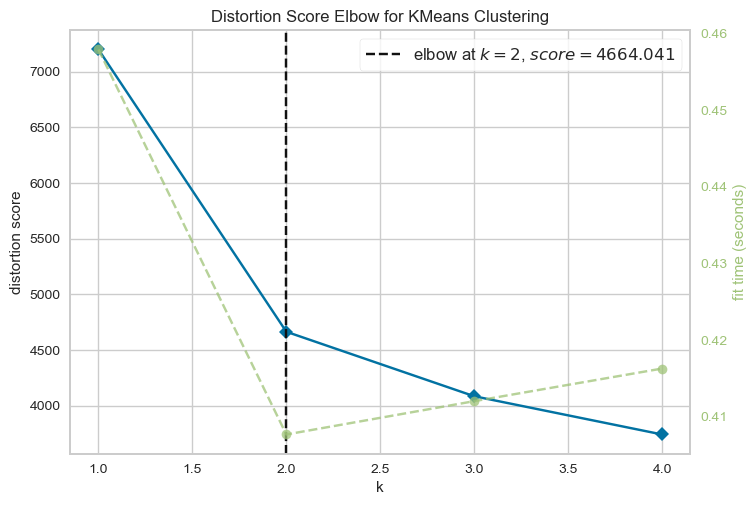

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [18]:
# A. Déterminer le nombre de clusters optimals- Méthode du coude

    # Utilisation de la méthode KElbowVisualizer pour créer la visualisation de la méthode du coude, on le veut entre 1 et 5 clusters
visualizer_coude = KElbowVisualizer(Kmeans_obj, k=(1,5))
    # Entraintement du visualiseur via les données explicatives, donc les variables avec les valeurs dans le jeu de données. Les dimensions de chaque billet
visualizer_coude.fit(X_train_scaled)
print("Méthode du coude :")
visualizer_coude.show()

    # Conclusion : Confirme que le nombre de clusters idéal est 2

#### 3.2.2 - Utilisation de la méthode de silhouette

Méthode de la silhouette :


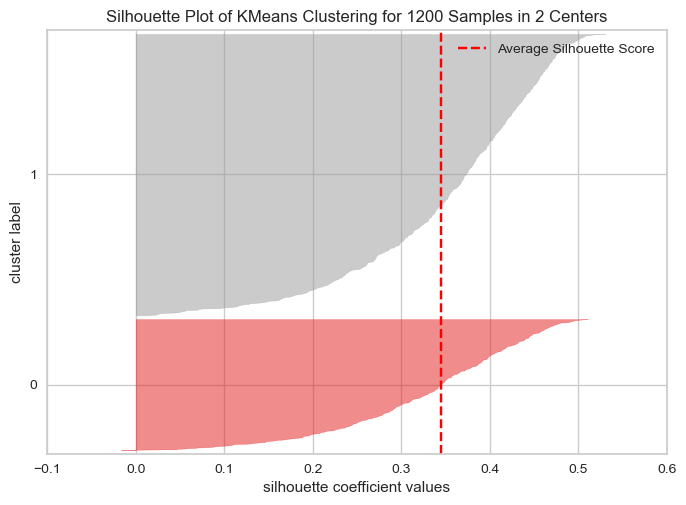

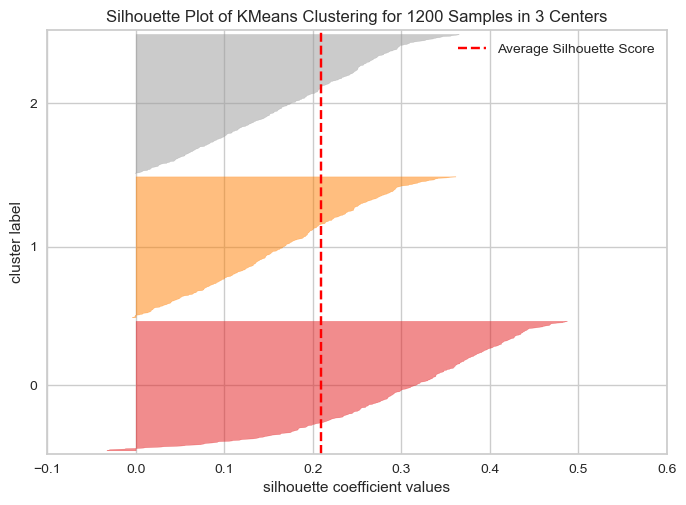

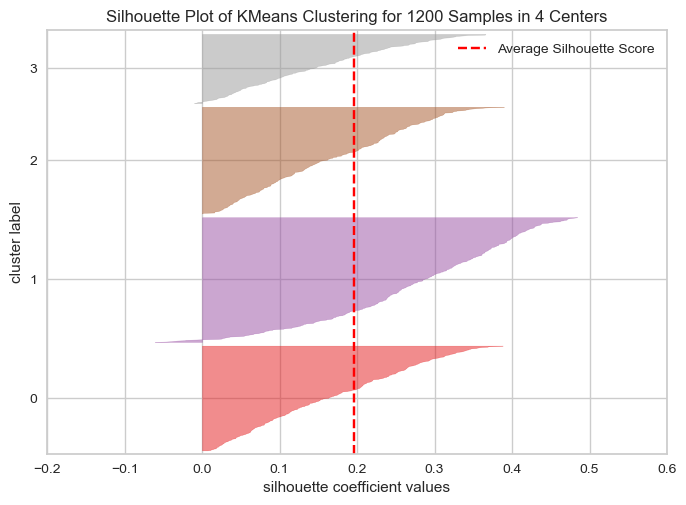

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1200 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [19]:
# Déterminer le nombre de clusters optimals - Méthode de la silhouette

# B. Déterminer le nombre de clusters optimals - Méthode de la silhouette
    # Pour la méthode de la silhouette on recherche à avoir le coefficient de silhouette le plus proche de 1 
        # Proche de 1 = Bien répartie dans l'interieure des clusters ET assez loin des autres clusters (pas de chevauchage) - LE TOP
        # Proche de 0 = Ambiguité au niveau de l'assignation des clusters et certaines distances entre et dans les clusters
        # Proche de -1 = Mal répartie, mauvaises assignation d'échantillon dans des clusters, mauvaises distances, etc.
    

    # On indique le nombre de cluster qui nous semble optimal (2 selon la méthode du coude, on vérifie) - A re faire et comparer les résultats
Kmeans_silhouette = KMeans(n_clusters=2)
visualizer_silhouette_2 = SilhouetteVisualizer(Kmeans_silhouette)
    # Entraintement du visualiseur 
visualizer_silhouette_2.fit(X_train_scaled)
print("Méthode de la silhouette :")
visualizer_silhouette_2.show()

    # On indique le nombre de cluster qui nous semble optimal (3 selon la méthode du coude, on vérifie) - A re faire et comparer les résultats
Kmeans_silhouette = KMeans(n_clusters=3)
visualizer_silhouette_3 = SilhouetteVisualizer(Kmeans_silhouette)
    # Entraintement du visualiseur
visualizer_silhouette_3.fit(X_train_scaled)
visualizer_silhouette_3.show()

    # On indique le nombre de cluster qui nous semble optimal (3 selon la méthode du coude, on vérifie) - A re faire et comparer les résultats
Kmeans_silhouette = KMeans(n_clusters=4)
visualizer_silhouette_4 = SilhouetteVisualizer(Kmeans_silhouette)
    # Entraintement du visualiseur
visualizer_silhouette_4.fit(X_train_scaled)
visualizer_silhouette_4.show()

    # Conclusion : Le nombre de clusters idéal est 2, valeur plus proche de 1 avec 0,5

## 3.3 - Entrainement du modèle du Kmeans via les données d'entrainement

In [20]:
# Utiliser algo agglomerative clustering
#https://www.youtube.com/watch?app=desktop&v=beuxGDhXHZQ

# Choix après visualisation de la méthode du coude OU méthode de la silhouette
  # Le choix optimal de cluster est de 2 dans notre cas
        
    # On va entrainer l'algo du Kmeans sur 2 clusters PUIS lui assigner les clusters
cluster_model = KMeans(n_clusters = 2)
        # Entraineemt des données
cluster_model.fit(X_train_scaled)

KMeans(n_clusters=2)

## 3.4 - Prédiction des clusters pour les données de test via le modèle entrainé avec les données d'entrainement

In [21]:
# Attribution des clusters pour les données de test
clusters_kmeans_test = cluster_model.predict(X_test_scaled)

## 3.5 - Rassemblement des données de vrai et faux billet ET les clusters pour les données de test

In [22]:
# Rassemblement des données des zones avec leurs clusters obtenus avec l'algo du Kmeans

   # Créer data frame avec les clusters et zone pour les données sans outliers
data_cluster_kmeans_test = pd.DataFrame({"is_genuine" : y_test, "cluster" : clusters_kmeans_test})

print(data_cluster_kmeans_test)

    # On inverse les clusters en indiquant 0 pour 1 et 1 pour 0 - pour suivre la logique de True et False - représente la valeur prédite
data_cluster_kmeans_test['new_cluster_predict'] = data_cluster_kmeans_test['cluster'].apply(lambda x: 0 if x == 1 else 1)

print(data_cluster_kmeans_test)

data_cluster_kmeans_test = data_cluster_kmeans_test[["is_genuine", "new_cluster_predict"]]

    # Passage des valeurs réelles cibles de test de True et False en binaire - False = 0 et True = 1
data_cluster_kmeans_test['is_genuine'] = data_cluster_kmeans_test['is_genuine'].apply(lambda x: 1 if x == True else 0)

print(data_cluster_kmeans_test)

      is_genuine  cluster
1116       False        0
1368       False        0
422         True        1
413         True        1
451         True        1
...          ...      ...
983         True        1
799         True        1
1265       False        0
1150       False        0
824         True        1

[300 rows x 2 columns]
      is_genuine  cluster  new_cluster_predict
1116       False        0                    1
1368       False        0                    1
422         True        1                    0
413         True        1                    0
451         True        1                    0
...          ...      ...                  ...
983         True        1                    0
799         True        1                    0
1265       False        0                    1
1150       False        0                    1
824         True        1                    0

[300 rows x 3 columns]
      is_genuine  new_cluster_predict
1116           0                    1


## 3.6 - Evaluation du modèle / Interprétation des résultats

In [23]:
# Plusieurs méthodes à cotrôler :
    # a. Matrice de confusion - Possible avec Scikit learn - Table qui va montrer les performance en comparant les prédiction du modèle avec les valeurs réelles de la variable que l'on cherche a prédire. Permet de visualiser les faux positifs, faux négatifs, vrais positifs et vrais négatifs
        # Elle se compose de :
            # VP (Vrai positif) = Les échantillons de classe positif (Vrai billet) sont correctement prédit comme positif par le modèle
            # FN (Faux négatif) = Les échantillons de classe positif (Vrai billet) sont mal prédit comme négatif (Faux billet) par le modèle
            # FP (Faux positif) = Les échantillons de classe négative (Faux billet) sont mal prédit comme positif (Vrai billet) par le modèle
            # VN (Vrai négatif) = Les échantillons de classe négative (Faux  billet) sont correctement prédit comme négatif par le modèle
        # Interprétation :
            # Plus les valeurs VP et VN  sont élevées et les valeurs FP et FN sont faibles, meilleure est la performance du modèle
            # Diverses métriques calculable via la matrice de confusion :
                # La précision - proportion d'échantillon positifs correctement classés parmi tous les échantillons positifs prédits par le modèle (pareil avec les négatif)-> VP / VP + FP OU pour les négatifs VN / VN + FN
                # Le rappel - proportion d'échantillons positifs correctement classés parmi tous les échantillons positifs réels dans l'ensemble de données (pareil avec les négatif) -> VP / VP + FN OU pour les négatifs VN / VN + FP
                # les taux de FP, FN, etc.
            # La diagonale principale de la matrice représente les prédictions correctes du modèle ET les cellules hors diagonale représentent les erreurs de classification


### 3.6.1 - Matrice de confusion

In [24]:
# Calcul de la matrice de confusion
conf_matrix = confusion_matrix(data_cluster_kmeans_test["is_genuine"], data_cluster_kmeans_test["new_cluster_predict"])
# Appel d'une fonction pour afficher de manière plus détaillée la matrice de confusion
    # VP | FN
    # FP | VN
display_confusion_matrice(conf_matrix)

    # Conclusion : Seulement 2 Faux négatif (Echantillon de classe TRUE, prédit incorrectement par le modèle, par FALSE) ET 298 bonne prédiction par rapport aux données réelles que ce soit des classes positives ou négatives
                    # Modèle très performant

# Mise en place de variable pour rendre les calculs dynamiques
VP = conf_matrix[1, 1]  # Vrai Positif
VN = conf_matrix[0, 0]  # Vrai Négatif
FP = conf_matrix[0, 1]  # Faux Positif
FN = conf_matrix[1, 0]  # Faux Négatif

# Calcul de la précision - VP / VP + FP - proportion de vrais positifs parmi tous les exemples prédits positifs
print('Précision sur la classe positive :', round((VP/(VP+FP))*100,1), ' %')

# Calcul du rappel - VP / VP + FN - proportion de vrais positifs parmi tous les exemples réellement positifs
print('Rappel sur la classe positive :', round((VP/(VP+FN))*100,1), ' %')

# Calcul du taux de Faux Positif  - FP / FP + VN
if (FP == 0):
    
    print('Taux de Faux Positif : 0 %')
    
else:
    
    print('Taux de Faux Positif :', round((FP/(FP+VN))*100,1), ' %')
    
# Calcul du taux de Faux Négatif - FN / FN + VP
print('Taux de Faux Négatif :', round((FN/(FN+VP))*100,1), ' %')

# Calcul du taux de Vrai positif - VP / VP + FN
print('Taux de Vrai Positif :', round((VP/(VP+FN)) * 100,1), ' %')

# Calcul du taux de Vrai Négatif - VN / VN + FP
print('Taux de Vrai Négatif :', round((VN/(VN+FP)) * 100,1), ' %')

    # Conclusion globale : 

Matrice de Confusion :
-----------------------
          Prédit Positif Prédit Négatif 
Réel Positif 1              109            
Réel Négatif 188            2              
-----------------------
Total des observations : 300
Précision sur la classe positive : 1.8  %
Rappel sur la classe positive : 1.1  %
Taux de Faux Positif : 99.1  %
Taux de Faux Négatif : 98.9  %
Taux de Vrai Positif : 1.1  %
Taux de Vrai Négatif : 0.9  %


### 3.6.2 - Calcul du F1-Score

In [25]:
rappel_true = round((VP/(VP+FN))*100,1)
precision_true = round((VP/(VP+FP))*100,1)

f1_kmeans = 2 * (precision_true * rappel_true) / (precision_true + rappel_true)

print(f1_kmeans, "%")

1.3655172413793104 %


## 3.7 - Optimisation du modèle 

In [26]:
# 1er version - Utilisation des données réelles et brutes pour créer le modèle de prédiction :
    # Rappel classe positive (Vrai billet) : 96,9 %
    # Précision classe positive (Vrai billet) : 100 %
    # Taux de faux positif : 5,5 %
    # Taux de faux negatif : 0 %
    # Taux de vrai positif : 100 %
    # Taux de vrai negatif : 94,5 %
        # Conclusion, très bon modèle, MAIS a plus de mal pour prédire les billets en vrai pour ceux qui sont réellement vrai, contrairement aux faux billets
# 2 eme version - Tentative d'utilisation de données normalisées via le Standard Scaler pour créer le modèle de prédiction :
    # Rappel classe positive (Vrai billet) : 99,5 %
    # Précision classe positive (Vrai billet) : 98,9 %
    # Taux de faux positif : 0,9 %
    # Taux de faux negatif : 1,1 %
    # Taux de vrai positif : 98,9 %
    # Taux de vrai negatif : 99,1 %
        # Conclusion, très bon modèle, prédit bien que ce soit les billets vrais OU faux

# Optimisation du modèle en passant par la modification des données via la normalisation des données utilisées pour l'entrainer, on a plus de données prédites parfaites MAIS on a moins de fluctuation entre les vrais et faux billets prédits

# 4 - Déduction du modèle le plus performant entre Régression logistique ET Kmeans - via ACP

In [27]:
# L'ACP est utile dans ce cas pour réduire les dimensions à 2 ou 3 pour visualiser en 2D OU 3D les performances des deux modèles
    # Donne une possibilité de l'interpréter dans un espace interprétable pour un humain

## 4.1 - Instanciation de l'ACP + Entrainement de l'ACP sur les données d'entrainements normalisées

In [28]:
# Récupération du nombre de variables explicatives utilisées pour l'entrainement des modèles (axes[1] = select colonne ET axes[0] = select les lignes)
nb_variable_explicative = len(X.axes[1])

# Travail sur toutes les dimensions utilisées dans les données, donc les 6 variables explicatives (on a 6 dimensions) - Sélection de 6 composantes
n_components = nb_variable_explicative

# Instanciation de notre ACP, ou l'on donne le nombre de composantes à avoir dans la configuration
acp = PCA(n_components=n_components)

# On entraine l'ACP sur les données scalées d'entrainement, les valeurs que l'on a centrées réduits via le standard scaler
acp = acp.fit(X_train_scaled)

## 4.2 - Affichage de la méthode du coude pour choisir la réduction dimensionnelle optimale entre 2 et 3

In [29]:
# Visualisation de l'information perdue entre 2 et 3 variables explicatives réduites (de base 6)

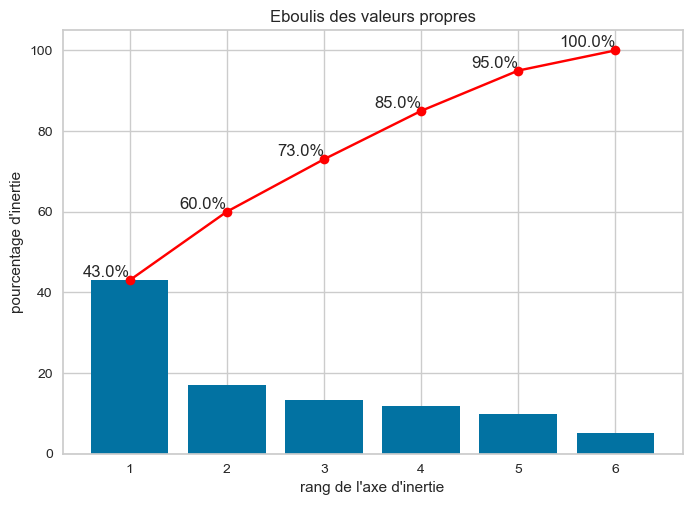

In [30]:
# Attribut qui permet de connaitre le pourcentage d'inertie/d'info obtenu pour chaque projection/composante (F1 = 47 %, F2 = 15 %, etc.)
acp.explained_variance_ratio_
# Stockage de ces degrè d'inertie dans une variable, passage en pourcentage et arrondi à 2
scree = (acp.explained_variance_ratio_*100).round(2)
scree

# Si on effectue une somme cummulé entre les deux premières composantes on obtient 47,16 (F1) + 15,65 (F2) + 13,68 (F3) + 11,91 (F4) = 88,4 % de l'information obtenu sur les données, il y a une perte de 12 % des informations si on s'arrête là 
scree_cum = scree.cumsum().round()
scree_cum

# Création d'une variable avec la liste de nos composantes (c'est là ou ou on obtient F1, F2, F3, F4, F5 et F6)
x_list = range(1, n_components+1)
list(x_list)

# Affichage du diagramme de l'ébouli des valeurs propres, avec la courbe de somme cummulé des degrè d'inertie
plt.bar(x_list, scree)
plt.plot(x_list, scree_cum,c="red",marker='o')
plt.xlabel("rang de l'axe d'inertie")
plt.ylabel("pourcentage d'inertie")
plt.title("Eboulis des valeurs propres")

# Ajouter des étiquettes de pourcentage
for i, txt in enumerate(scree_cum):
    plt.text(x_list[i], scree_cum[i], f'{scree_cum[i]}%', ha='right', va='bottom')


plt.show(block=False)

    # Conclusion : On choisit de réduire à 2 dimensions, nous avons 60 % de l'information restante, ce qui est convenable

## 4.3 - Entrainement et application de l'ACP avec la réduction optimale sélectionnée - Entrainement ET application sur les données normalisées d'entrainemenet PUIS Application sur les données normalisées de tests

In [31]:
# Réduction de dimension avec PCA, entrainement du modèle de PCA sur les données d'entraînement ET application
acp = PCA(n_components=2)
X_train_acp = acp.fit_transform(X_train_scaled)

# Application de la réduction de dimension avec PCA pour les données de test (en utilisant la même transformation que pour les données d'entraînement)
X_test_acp = acp.transform(X_test_scaled)

## 4.4 - Affichage des subplots sur les données de test

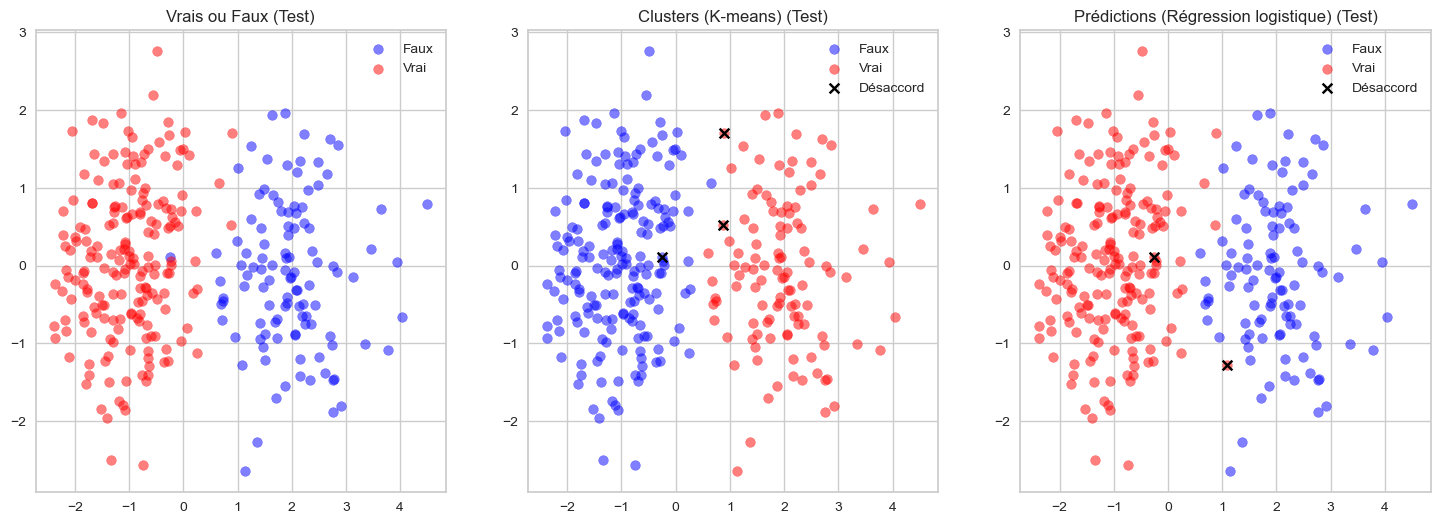

In [32]:
# On veut afficher 3 graphiques montrant les performances des deux modèles précédent mis en place :
    # 1er graphique : Afficher les billets vrai ou faux au total
    # 2eme graphique : Afficher les billets vrai ou faux par rapport aux clusters prédits obtenus via le kmeans
    # 3eme graphique : Afficher les billets vrai ou faux par rapport à la prédiction via la régression logistique

# Données prédites sur les données de test via le modèle de régression logistique
regression_log_prediction = y_pred

# Données prédites sur les données de test via le modèle de Kmeans
kmeans_test_prediction = data_cluster_kmeans_test["new_cluster_predict"].values

# Comparaison des prédictions avec les valeurs réelles
    # Différent de CAR  true (vrai billet) et false (faux billet) -> Donc indique les points qui sont mal prédits
regression_log_disagreements = (regression_log_prediction != y_test)
    # Egal a CAR  true (faux billet) et false (vrai billet) -> Donc indique les points qui sont mal prédits
kmeans_disagreements = (kmeans_test_prediction == y_test)

# Affichage des subplots pour les données de test
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Subplot 1 : Vrais ou Faux (Test)
axes[0].scatter(X_test_acp[y_test==0, 0], X_test_acp[y_test==0, 1], label='Faux', color='blue', alpha=0.5)
axes[0].scatter(X_test_acp[y_test==1, 0], X_test_acp[y_test==1, 1], label='Vrai', color='red', alpha=0.5)
axes[0].set_title('Vrais ou Faux (Test)')
axes[0].legend()

# Subplot 2 : Clusters obtenus via K-means (Test)
# Affichage des clusters avec les points correctement prédits en couleur normale et les points incorrectement prédits en couleur distincte
axes[1].scatter(X_test_acp[kmeans_test_prediction==0, 0], X_test_acp[kmeans_test_prediction==0, 1], c='blue', label='Faux', alpha=0.5)
axes[1].scatter(X_test_acp[kmeans_test_prediction==1, 0], X_test_acp[kmeans_test_prediction==1, 1], c='red', label='Vrai', alpha=0.5)
# Ajout des points incorrectement prédits en couleur distincte (par exemple, noir)
axes[1].scatter(X_test_acp[kmeans_disagreements, 0], X_test_acp[kmeans_disagreements, 1], color='black', marker='x', label='Désaccord')
axes[1].set_title('Clusters (K-means) (Test)')
axes[1].legend()

# Subplot 3 : Prédictions via régression logistique (Test)
# Affichage des points correctement prédits en couleur normale
axes[2].scatter(X_test_acp[regression_log_prediction==0, 0], X_test_acp[regression_log_prediction==0, 1], c='blue', label='Faux', alpha=0.5)
axes[2].scatter(X_test_acp[regression_log_prediction==1, 0], X_test_acp[regression_log_prediction==1, 1], c='red', label='Vrai', alpha=0.5)
# Ajouter les points de désaccord en couleur distincte (par exemple, noir)
axes[2].scatter(X_test_acp[regression_log_disagreements, 0], X_test_acp[regression_log_disagreements, 1], color='black', marker='x', label='Désaccord')
axes[2].set_title('Prédictions (Régression logistique) (Test)')
axes[2].legend()

plt.show()

# 5 - Forêt Aléatoire

In [33]:
# La méthode d'apprentissage de la forêt aléatoire combine les prédictions de plusieurs arbres de décision permettant l'obtention d'une prédiction davantage robuste et précise
# Elle est utile dans ces cas :
    # 1. Utilisable en classification et régression
        # Classification, très efficace pour les ensembles de données avec un grand nombre de variables explicatives et relation complexe avec la variable cible
    # 2. Robuste face aux données bruitées et aberrantes, réduisant l'overfitting en moyennant les prédictions des différents arbres de décision. Cela se fait par le pruning/élagage qui consiste  supprimer les branches de l'arbre qui ne sont pas nécessaires pour la prédiction des classes, réduisant la complexité ET l'overfitting des données.
    # 3. Possibilité d'utiliser cette méthode sans avoir géré les valeurs NA au préalable
    # 4. Gère très bien les ensembles de données comprenant un grand nombre de dimensions (variable explicative)
    
# Arbre de classification -> Prédiction d'une variable catégorielle/qualitative
# Arbre de régression -> Prédiction d'une variable continue/quantitative

# Principe important pour la création d'arbre de décision performant - l'impureté pour choisir les meilleurs noeuds de décision ET l'homogénéité qui est en lien direct avec la pureté ou non, pour savoir si les échantillons sont bien réparties entre les noeuds de décision

# https://www.youtube.com/watch?v=EgyIY9vKrcU

### 5.1 - Récupération des données + split des données de test et d'entrainement + normalisation des données via Standard Scaler

In [34]:
    # Récupération des données d'un côté les valeurs ET d'un côté les valeur binaire de la typologie des billets
# Pas besoin, effectué précédemment via la régression logistique : X = les valeurs ET y le type des billets

    # Split des données d'entrainement et de test
# Pas besoin, effectué précédement via la régression logisitique : X_train, y_train, X_test et y_test

    # Normalisation des données via les données d'entrainement car plus grande part (80 %) et utilisation de ce modèle de normalisation pour normaliser les données de test (20 %) - via le Standard Scaler
# Pas besoin, effectué précédement via la régression logisitique : X_train_scaled ET X_test_scaled

## 5.2 - Initialisation de la forêt aléatoire + Validation croisée pour tester les performances du modèle et définir les meilleurs paramètres

In [35]:
# Entraînement du modèle de forêt aléatoire
        # 1. Taille de l'ensemble de données -> Plus l'ensemble de données est grand PLUS on peut utiliser un grand nombre d'estimateur sans risquer l'overfitting
        # 2. Complexité du problème -> Plus le problème et les relations sont complexes (non linéaire) PLUS il faut un grand nombre d'estimateur pour capter la complexité SI ce sont des relations "simple", on peut utiliser un nombre plus faible d'estimateur
        # 3. Temps de calcul : Plus il y a d'estimateur Plus le temps de calcul est long - adapter selon les couts et le temps dispo pour le projet
        # 4. Gestion de l'overffing, si le modèle prédit bien sur les données d'entrainement et moins bien sur les données de test, on peut essayer de réduire le nombre d'estimateurs pour réduire la complexité du modèle et améliorer sa capacité de généralisation

#---#

# Il existe plusieurs métriques utile pour visualiser la performance, on dit ça le scoring, voici une liste :
    # 1. Accuracy (Précision) : Ratio du nombre de prédiction correctes au nombre total de prédictions
        # Utile quand : Approprié pour des classes équilibrées, où le nombre de vraies et de fausses classes est à peu près égal
    # 2. Precision (Précision) : Le ratio des vrais positifs au nombre total de prédictions positives
        # Utile quand : Important lorsqu'il y a un coût élevé associé aux faux positifs
    # 3. Recall (Rappel) : Le ratio des vrais positifs au nombre total d'échantillons positifs réels
        # Utile quand : Important lorsqu'il y a un coût élevé associé aux faux négatifs
    # 4. F1 Score : La moyenne harmonique de la précision et du rappel
        # Utile quand : Lorsqu'on a besoin d'un équilibre entre la précision et le rappel
    # 5. F-beta Score : Mesure généralisée du F1-Score, mettant plus d'importance sur le Recall (rappel - F-Beta Score > 1) OU sur la Precision (Précision - F-Beta Score < 1)
        # Utile quand  :  Lorsque qu'on souhaite ajuste la précision et le rappel (prévilégier la détection des faux positifs OU faux négatifs)
    # 6. ROC AUC: La zone sous la courbe ROC, qui est un graphique de la sensibilité (rappel) contre le taux de faux positifs
        # Utile quand : Pour les problèmes de classification binaire, indépendamment du seuil de classification
    # 7. Log Loss : Mesure de performance des modèles de classification où les prédictions de probabilité sont fournies en tant que sortie
        # Uitle quand : Pour évaluer les probabilités prédictives fournies par les modèles
        

    # Conclusion : Utilisation du scoring "F-beta Score" pour pouvoir ajuster notre souhait de privilégier le recall à la précision pour mettre un focus sur les faux négatifs
    
#---#

# Définir le F-beta score comme métrique de scoring - C'est une mesure généralisée du F1 score (contient précision, recall, etc.) qui permet de mettre plus d'importance sur le rappel OU la précision
    # Il faut optimiser le Fbeta score pour que le modèle puisse davantage détecter les faux négatifs (donc vrai positif) car cela pourrait être couteux (présence de fraude)
        # Pour cela, on va chercher à pénaliser la précision et maximiser le rappel, et la technique de scoring du F beta score est idéale
        # Si Fbeta score SUPERIEUR à 1, alors on donnera plus de poids au rappel qu'à la précision. Si égal à 2, alors 2 fois plus de poids pour le rappel que la précision
beta = 2 
fbeta_scorer = make_scorer(fbeta_score, beta=beta)

# Définir les paramètres à tester dans la recherche randomisée
    # n_estimators -> Le nombre d'estimateurs correspond au nombre d'arbres de décision individuels qui composent la forêt, c'est un hyperparamètre important du modèle, voici comment en choisir le nombre :
    # max_depth -> Profondeur maximale des abres, permet de contrôler la complexité des arbres et éviter le surajustement - éviter que le modèle soit trop adapté à la situation des données d'entrainement, donc pourra pas généraliser sa décision sur d'autres données/situations
    # min_samples_split (split = noeud = question OU statut qui attend une réponse, plusieurs réponses possibles à la suite (leaf) )-> Permet de contrôler le nombre minimum d'échantillons requis pour diviser un noeud dans la random forest - cela va influencer la complexité de l'arbre
    # min_sample_leaf (leaf = feuille = réponses possibles d'un noeuds de décision (split)) -> Correspond au nombre de réponse minimal que peut avoir un noeud (split)
    # bootstrap -> Indique si les échantillons doivent être tirés avec ou sans remise (avec remise = si on peut tirer à nouveau les réponses passées ET à l'inverse si on ne peut pas re tirer les réponses passées)
    # criterion -> Méthode pour mesurer la pureté des noeuds
    # class_weight -> Gestion automatique ou non du déséquilibre des classes (si plus de vrai OU de faux dans les échantillons alors voir si c'est plus interressant de pas les gérer OU de les gérer avec un ajustement automatique par pondération)
param_dist = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced', 'balanced_subsample']
}

# Initialiser le modèle de forêt aléatoire
rf_model = RandomForestClassifier(random_state=42)

# Initialiser la GridSearchCV
    # On va utiliser la validation croisée pour trouver le meilleur "estimateur" comme paramètre pour le modèle
        # Possibilité d'utiliser la méthode Grid Search CV -> Mise en place de la validation croisée sous 5 plis 
            # Qualité : Plus précis 
            # Défaut : Temps de calcul plus élevé 
#grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='accuracy')
        # Choix d'utiliser la méthode de randomizer search CV -> Mise en place de la validation croisée sous 5 plis 
            # Qualité : Temps de calcul bas
            # Défaut : Moins précis (mais pas besoin d'une grande précision dans le cas du projet qui est assez simple sur la composition des données, quasi parfait)
random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_dist, 
                                   n_iter=100, cv=5, scoring=fbeta_scorer, random_state=42, n_jobs=-1)


# Exéction de la validation croisée via Grid Search CV sur les données d'entrainement
#grid_search.fit(X_train, y_train)
random_search.fit(X_train, y_train)

# Affichage des résultats de la validation croisée pour déterminer lequel estimateur choisir pour entrainer le modèle de forêt aléatoire
#results_df = pd.DataFrame(grid_search.cv_results_)
results_df = pd.DataFrame(random_search.cv_results_)

#print(results_df[['param_n_estimators', 'mean_test_score', 'std_test_score']])
    # Afficher les meilleurs paramètres trouvés par la recherche sur la grille
#print("Meilleurs paramètres :", grid_search.best_params_)
    # Afficher la meilleure précision trouvée par la recherche sur la grille
#print("Meilleure précision :", grid_search.best_score_)


print(results_df[['param_n_estimators', 'param_max_depth', 'param_min_samples_split', 
                  'param_min_samples_leaf', 'param_bootstrap', 'param_criterion', 
                  'param_class_weight', 'mean_test_score', 'std_test_score']])
# Afficher les meilleurs paramètres trouvés par la recherche randomisée
print("Meilleurs paramètres :", random_search.best_params_)
# Afficher le meilleur F-beta score trouvé par la recherche randomisée
print("Meilleur F-beta score :", random_search.best_score_)

    # Conclusion : le meilleur estimateur a utiliser est 100. Il obtient le meilleur score ex-aequo à 150 et 200 MAIS surtout c'est le plus petit nombre, donc permettra de gagner dans le temps de process, car moins d'arbre individuel dans la forêt
                #  meilleur min_sample_split = 2
                #  meilleur min_sample_leaf = 1
                #  meilleur max_depth = 20
                #  meilleur criterion = gini
                #  meilleur class_weight = none (aucun ajustement automatique)
                #  meilleur bootstrap = True (tirage avec remise)

   param_n_estimators param_max_depth param_min_samples_split  \
0                 100              40                      10   
1                 100              40                       2   
2                 100              30                       5   
3                 100              50                       2   
4                 100            None                       5   
..                ...             ...                     ...   
95                100              50                       5   
96                 50            None                      10   
97                150              30                       5   
98                 50              30                       2   
99                200              10                       5   

   param_min_samples_leaf param_bootstrap param_criterion  param_class_weight  \
0                       1           False            gini  balanced_subsample   
1                       1           False         entropy

## 5.3 - Entrainement du modèle avec les meilleurs paramètres

In [36]:
best_rf_model = random_search.best_estimator_

## 5.4 - Prédiction pour les données de test via le modèle entrainé avec les données d'entrainement et les meilleurs paramètres

In [37]:
rf_test_predictions = best_rf_model.predict(X_test)

## 5.5 - Evaluation du modèle / Interprétation des résultats

In [38]:
# Plusieurs méthodes/métriques à contrôler :
    # a. Accuracy (Précision) :
        # Mesure de la performance globale du modèle -> Nombre de prédictions correctes / Nombre total d'échantillons
        # Varie entre 0 et 1 
            # Plus c'est proche de 1, plus la prédiction est parfaite 
            # Plus c'est proche de 0, plus la prédiction est mauvaise/incorrecte
        # CEPENDANT, n'est pas bon a mener seul quand les classes sont déséquilibrées (si plus de vrai que de faux billets dans les données)
    # b. F1 Score 
        # Mesure de la précision et du rappel, comme vu précédemment.
        # Utile quand les classes sont déséquilibrés dans le jeu de données
        # F1 = 2 / (Précision * Recall) / (Précision + Recall)
        # Varie entre 0 et 1 
            # Plus c'est proche de 1, plus la prédiction est parfaite 
            # Plus c'est proche de 0, plus la prédiction est mauvaise/incorrecte
    # c. F-beta score 
    # d. Matrice de confusion - utile pour faciliter l'interprétation des résultats

### 5.5.1 - Accuracy

In [39]:
rf_accuracy = accuracy_score(y_test, rf_test_predictions)
print("Accuracy du meilleur modèle de forêt aléatoire :", rf_accuracy)

Accuracy du meilleur modèle de forêt aléatoire : 0.9933333333333333


### 5.5.2 - F1 Score

In [40]:
# Utilisation du F1-Score, car jeu de données déséquilibrés avec plus de classe positive que négative
    # Calcul du F1-score
f1_random_forest = f1_score(y_test, rf_test_predictions)

print("F1-score :", f1_random_forest)

F1-score : 0.9947643979057591


### 5.5.3 - F-Beta Score

In [41]:
random_forest_fbeta_score = random_search.best_score_
print("F-Beta Score :", random_forest_fbeta_score)

F-Beta Score : 0.994323721014988


### 5.5.4 - Matrice de confusion

In [70]:
# Calculer la matrice de confusion
conf_matrix = confusion_matrix(y_test, rf_test_predictions)

# Afficher la matrice de confusion
display_confusion_matrice(conf_matrix)

Matrice de Confusion :
-----------------------
          Prédit Positif Prédit Négatif 
Réel Positif 108            2              
Réel Négatif 0              190            
-----------------------
Total des observations : 300


## 5.6 - Optimisation du modèle 

In [42]:
# 1er version - Utilisation des données réelles et brutes pour créer le modèle de prédiction :
    # Accuracy : 0.9933333333333333
    # F1 Score : 0.9947643979057591
    # F-Beta Score : 0.994323721014988
        # Conclusion, très bon modèle
        
# Pas utile de faire une version avec des données normalisées - car traité de manière indépendante pour chaque variable explicative/dimension et donc pas de lien a avoir

# 6 - XGboost (eXtreme Gradient Boosting)

In [43]:
# C'est un modèle de boosting qui va utiliser le gradient et vient combiner plusieurs modèles qui vont être complémentaire pour venir améliorer les prédictions à chaque étape de progression

# Le boosting c'est une méthode d'apprentissage automatique qui vise à créer une prédiction précise en combinant plusieurs sous modèles (enchainement successif de modèle de régression linéaire par exemple) en essayant d'améliorer à chaque étape (itération) les mauvaises prédictions des modèles précédents

# Le boosting par gradient est une méthode spécifique de boosting qui utilise le gradient de la fonction de perte (direction qui minimisera l'erreur) pour améliorer les modèles
    # La descente de gradient

# Fonctionnement en plusieurs point de cette méthode d'apprentissage :

    # Boosting : XGBoost est basé sur le principe du boosting, qui est une technique d'apprentissage ensembliste où les modèles sont construits séquentiellement, chaque modèle cherchant à corriger les erreurs des modèles précédents. Cela permet d'améliorer progressivement les performances du modèle en combinant plusieurs modèles plus faibles pour former un modèle plus fort.
    # Gradient Boosting : XGBoost utilise une variante du boosting appelée gradient boosting, où les nouveaux modèles sont ajoutés pour réduire le gradient d'une fonction de perte différentiable. Les nouveaux modèles sont ajustés de manière itérative pour minimiser cette fonction de perte, ce qui permet de trouver des prédictions optimales.
    # Arbres de décision : Les modèles de base utilisés dans XGBoost sont généralement des arbres de décision, bien que d'autres types de modèles puissent également être utilisés. Les arbres de décision sont construits de manière itérative pour maximiser la réduction d'erreur à chaque étape.
    # Regularization : XGBoost utilise des techniques de régularisation pour éviter le surapprentissage et améliorer la généralisation du modèle. Cela inclut la régularisation L1 et L2 sur les poids des arbres et la régularisation de la profondeur des arbres pour contrôler leur complexité.
    # Optimisation de la fonction de perte : XGBoost utilise des techniques d'optimisation avancées pour minimiser la fonction de perte, telles que le calcul efficace des gradients et des hessiens, ainsi que des algorithmes d'optimisation efficaces comme la descente de gradient stochastique et la descente de gradient coordonnée.
    # Parallélisme : XGBoost est conçu pour être hautement parallélisé, ce qui lui permet de s'exécuter efficacement sur des architectures distribuées et de tirer parti des ressources matérielles disponibles.

# Les avantages de son utilisation :
    # Performant et des calculs rapides
    # La flexibilité concernant les paramètres à indiquer dans le modèle
    # Bonne gestion des données NA, pas obligé d'avoir mener un traitement au préalable sur les données NA
    # Se compose de technique de régularisation qui va venir ajouter des méthodes de pénalisation pour éviter l'overfitting
    # La gestion par parralélisme, le rend efficace et rapide 
    # L'abre de décision est le modèle de base utilisé, comme la plupart des modèles de boosting
    
# https://www.youtube.com/watch?v=nfe4puWvX4A

# D'autres modèle de ce genre existent, ils fonctionnent différemment sur certains points :
    # CatBoost
    # LightGBM

### 6.1 - Récupération des données + split des données de test et d'entrainement + normalisation des données via Standard Scaler

In [44]:
    # Récupération des données d'un côté les valeurs ET d'un côté les valeur binaire de la typologie des billets
# Pas besoin, effectué précédemment via la régression logistique : X = les valeurs ET y le type des billets

    # Split des données d'entrainement et de test
# Pas besoin, effectué précédement via la régression logisitique : X_train, y_train, X_test et y_test

    # Normalisation des données via les données d'entrainement car plus grande part (80 %) et utilisation de ce modèle de normalisation pour normaliser les données de test (20 %) - via le Standard Scaler
# Pas besoin, effectué précédement via la régression logisitique : X_train_scaled ET X_test_scaled

## 6.2 - Initialisation de XGBoost + Validation croisée pour tester les performances du modèle et définir les meilleurs paramètres

In [45]:
# Définir les paramètres à tester dans la recherche randomisée pour le modèle XGBoost
    # n_estimators -> Le nombre d'estimateurs correspond au nombre d'arbres de décision individuels qui composent la forêt, c'est un hyperparamètre important du modèle, voici comment en choisir le nombre :
    # max_depth -> Profondeur maximale des abres, permet de contrôler la complexité des arbres et éviter le surajustement - éviter que le modèle soit trop adapté à la situation des données d'entrainement, donc pourra pas généraliser sa décision sur d'autres données/situations
    # learning_rate -> Taux d'apprentissage. Réduit la contribution de chaque arbre et permet d'améliorer la robustesse du modèle
    # subsample -> Proportion d'échantillons utilisés pour chaque arbre
    # colsample_bytree -> Proportion de features utilisées pour chaque arbre
    # gamma -> Réduction minimale de la perte nécessaire pour qu'une division soit effectuée. Plus la valeur est élevée, plus le modèle est conservateur
    # reg_alpha -> Régularisation L1. Encourage les poids des features à devenir 0
    # reg_lambda ->  Régularisation L2. Réduit la complexité du modèle en pénalisant les grands poids.
param_dist = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'reg_alpha': [0, 0.01, 0.05, 0.1, 1],
    'reg_lambda': [0, 0.01, 0.05, 0.1, 1]
}

# Initialiser le F-beta score comme métrique de scoring, avec un beta élevé pour pénaliser les faux négatifs - Comme pour le modèle précédent
fbeta_scorer = make_scorer(fbeta_score, beta=2)

# Initialiser le modèle XGBoost pour la classification
xgb_model = xgb.XGBClassifier(objective='binary:logistic', random_state=42)

# Initialiser RandomizedSearchCV pour le modèle XGBoost
random_search = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_dist, 
                                   n_iter=100, cv=5, scoring=fbeta_scorer, random_state=42, n_jobs=-1)

# Exécution de la validation croisée via RandomizedSearchCV sur les données d'entraînement
random_search.fit(X_train, y_train)

# Affichage des résultats de la validation croisée pour déterminer les meilleurs paramètres
results_df = pd.DataFrame(random_search.cv_results_)
print(results_df[['param_n_estimators', 'param_max_depth', 'param_learning_rate', 
                  'param_subsample', 'param_colsample_bytree', 'param_gamma', 
                  'param_reg_alpha', 'param_reg_lambda', 'mean_test_score', 'std_test_score']])

# Afficher les meilleurs paramètres trouvés par la recherche randomisée
print("Meilleurs paramètres :", random_search.best_params_)

# Afficher le meilleur F-beta score trouvé par la recherche randomisée
print("Meilleur F-beta score :", random_search.best_score_)

    # Conclusion : le meilleur estimateur a utiliser est 100. Il obtient le meilleur score ex-aequo à 150 et 200 MAIS surtout c'est le plus petit nombre, donc permettra de gagner dans le temps de process, car moins d'arbre individuel dans la forêt
                #  meilleur subsample = 0.9
                #  meilleur reg_lambda = 1
                #  meilleur reg_alpha = 0
                #  meilleur max_depth = 3
                #  meilleur learning_rate = 0.1
                #  meilleur gamma = 0.3
                #  meilleur colsample_bytree = 0.6

   param_n_estimators param_max_depth param_learning_rate param_subsample  \
0                 200               6                0.01             0.9   
1                 150               8                0.05             0.8   
2                 200              10                 0.1             0.8   
3                 150               6                0.05             0.9   
4                 100               9                 0.3             0.9   
..                ...             ...                 ...             ...   
95                100               9                 0.2             1.0   
96                150              10                 0.1             1.0   
97                150              10                 0.1             0.7   
98                200               8                 0.3             1.0   
99                100               6                0.05             0.6   

   param_colsample_bytree param_gamma param_reg_alpha param_reg_lambda  \
0

## 6.3 - Entrainement du modèle avec les meilleurs paramètres

In [46]:
# Utiliser le modèle avec les meilleurs paramètres trouvés
best_xgb_model = random_search.best_estimator_

## 6.4 - Prédiction sur les données de test

In [47]:
# Faire des prédictions sur l'ensemble de test
xgboost_pred = best_xgb_model.predict(X_test)

## 6.5 - Evaluation du modèle / Interprétation des résultats

In [48]:
# Plusieurs méthodes/métriques à contrôler :
    # a. Accuracy (Précision) :
        # Mesure de la performance globale du modèle -> Nombre de prédictions correctes / Nombre total d'échantillons
        # Varie entre 0 et 1 
            # Plus c'est proche de 1, plus la prédiction est parfaite 
            # Plus c'est proche de 0, plus la prédiction est mauvaise/incorrecte
        # CEPENDANT, n'est pas bon a mener seul quand les classes sont déséquilibrées (si plus de vrai que de faux billets dans les données)
    # b. F1 Score 
        # Mesure de la précision et du rappel, comme vu précédemment.
        # Utile quand les classes sont déséquilibrés dans le jeu de données
        # F1 = 2 / (Précision * Recall) / (Précision + Recall)
        # Varie entre 0 et 1 
            # Plus c'est proche de 1, plus la prédiction est parfaite 
            # Plus c'est proche de 0, plus la prédiction est mauvaise/incorrecte
    # c. F-Beta Score
    # d. Matrice de confusion - utile pour faciliter l'interprétation des résultats

### 6.5.1 - Accuracy

In [49]:
# Calcul de l'accuracy des prédictions
accuracy = accuracy_score(y_test, xgboost_pred)
print("Accuracy du modèle XGBoost :", accuracy)

Accuracy du modèle XGBoost : 0.99


### 6.5.2 - F1 Score

In [50]:
# Calcul du F1 score des prédictions
f1_score_xgboost = f1_score(y_test, xgboost_pred)
print("F1 score des prédictions XGBoost :", f1_score_xgboost)

F1 score des prédictions XGBoost : 0.9921671018276762


### 6.5.3 - F-Beta Score

In [51]:
xgboost_fbeta_score = random_search.best_score_
print("F-Beta Score :", xgboost_fbeta_score)

F-Beta Score : 0.9953119894883293


### 6.5.4 - Matrice de confusion

In [71]:
# Calculer la matrice de confusion
conf_matrix = confusion_matrix(y_test, xgboost_pred)

# Afficher la matrice de confusion
display_confusion_matrice(conf_matrix)

Matrice de Confusion :
-----------------------
          Prédit Positif Prédit Négatif 
Réel Positif 107            3              
Réel Négatif 0              190            
-----------------------
Total des observations : 300


## 6.6 - Optimisation du modèle 

In [52]:
# 1er version - Utilisation des données réelles et brutes pour créer le modèle de prédiction :
    # Accuracy : 0.9966666666666667
    # F1 Score : 0.9973753280839895
    # F - Beta score : 0.9953119894883293
        # Conclusion, très bon modèle

# Pas utile de faire une version avec des données normalisées - car traité de manière indépendante pour chaque variable explicative/dimension et donc pas de lien a avoir

# 7 - Stacking (Forêt aléatoire ET XGBoost)

### 7.1 - Récupération des données + split des données de test et d'entrainement + normalisation des données via Standard Scaler

In [53]:
    # Récupération des données d'un côté les valeurs ET d'un côté les valeur binaire de la typologie des billets
# Pas besoin, effectué précédemment via la régression logistique : X = les valeurs ET y le type des billets

    # Split des données d'entrainement et de test
# Pas besoin, effectué précédement via la régression logisitique : X_train, y_train, X_test et y_test

    # Normalisation des données via les données d'entrainement car plus grande part (80 %) et utilisation de ce modèle de normalisation pour normaliser les données de test (20 %) - via le Standard Scaler
# Pas besoin, effectué précédement via la régression logisitique : X_train_scaled ET X_test_scaled

## 7.2 - Initialisation du modèle de Stacking + Validation croisée pour tester les performances du modèle et définir les meilleurs paramètres

In [54]:
# Définir le modèle de stacking avec les modèles de base et le final estimator
stacking_model = StackingClassifier(
    estimators=[
        ('random_forest', best_rf_model),
        ('xgboost', best_xgb_model)
    ],
    final_estimator=LogisticRegression()
)

# Définir les paramètres à tester pour le final estimator dans le modèle de stacking
    # final_estimator_C -> 
param_dist_final_estimator = {
    'final_estimator__C': [0.001, 0.01, 0.1, 1, 10, 100]  # Paramètre de régularisation pour la régression logistique
}

# Initialiser le F-beta score comme métrique de scoring, avec un beta élevé pour pénaliser les faux négatifs - Comme pour le modèle précédent
fbeta_scorer = make_scorer(fbeta_score, beta=2)

# Initialiser RandomizedSearchCV pour le modèle de stacking
random_search_stacking = RandomizedSearchCV(estimator=stacking_model, param_distributions=param_dist_final_estimator, 
                                            n_iter=100, cv=5, scoring=fbeta_scorer, random_state=42, n_jobs=-1)

# Entraîner le modèle de stacking sur les données d'entraînement
random_search_stacking.fit(X_train_scaled, y_train)

# Afficher les meilleurs paramètres trouvés par la recherche aléatoire pour le final estimator
print("Meilleurs paramètres pour le final estimator du modèle de stacking :", random_search_stacking.best_params_)

print("F-beta score du modèle de stacking :", random_search_stacking.best_score_)

    # Conclusion : le meilleur final_estimator_c est 0.01 

Meilleurs paramètres pour le final estimator du modèle de stacking : {'final_estimator__C': 0.01}
F-beta score du modèle de stacking : 0.9953256391489841


## 7.3 - Entrainement du modèle avec les meilleurs paramètres

In [55]:
# Utiliser le modèle avec les meilleurs paramètres trouvés
best_stacking_model = random_search_stacking.best_estimator_

## 7.4 - Prédiction sur les données de test

In [56]:
# Faire des prédictions sur l'ensemble de test
stacking_pred = best_stacking_model.predict(X_test_scaled)

## 7.5 - Evaluation du modèle / Interprétation des résultats

In [57]:
# Plusieurs méthodes/métriques à contrôler :
    # a. Accuracy (Précision) :
        # Mesure de la performance globale du modèle -> Nombre de prédictions correctes / Nombre total d'échantillons
        # Varie entre 0 et 1 
            # Plus c'est proche de 1, plus la prédiction est parfaite 
            # Plus c'est proche de 0, plus la prédiction est mauvaise/incorrecte
        # CEPENDANT, n'est pas bon a mener seul quand les classes sont déséquilibrées (si plus de vrai que de faux billets dans les données)
    # b. F1 Score 
        # Mesure de la précision et du rappel, comme vu précédemment.
        # Utile quand les classes sont déséquilibrés dans le jeu de données
        # F1 = 2 / (Précision * Recall) / (Précision + Recall)
        # Varie entre 0 et 1 
            # Plus c'est proche de 1, plus la prédiction est parfaite 
            # Plus c'est proche de 0, plus la prédiction est mauvaise/incorrecte
    # c. F-Beta Score 
    # d. Matrice de confusion - utile pour faciliter l'interprétation des résultats

### 7.5.1 - Accuracy

In [58]:
# Calcul de l'accuracy des prédictions
accuracy = accuracy_score(y_test, stacking_pred)
print("Accuracy du modèle de stacking :", accuracy)

Accuracy du modèle de stacking : 0.9866666666666667


### 7.5.2 - F1 Score

In [59]:
# Calcul du F1 score des prédictions
f1_score_xgboost = f1_score(y_test, stacking_pred)
print("F1 score des prédictions stacking :", f1_score_xgboost)

F1 score des prédictions stacking : 0.9895833333333333


### 7.5.3 - F-Beta Score

In [60]:
stacking_fbeta_score = random_search_stacking.best_score_
print("F-Beta Score :", stacking_fbeta_score)

F-Beta Score : 0.9953256391489841


### 7.5.4 - Matrice de confusion

In [72]:
# Calculer la matrice de confusion
conf_matrix = confusion_matrix(y_test, stacking_pred)

# Afficher la matrice de confusion
display_confusion_matrice(conf_matrix)

Matrice de Confusion :
-----------------------
          Prédit Positif Prédit Négatif 
Réel Positif 106            4              
Réel Négatif 0              190            
-----------------------
Total des observations : 300


## 7.6 - Optimisation du modèle 

In [61]:
# 1er version - Utilisation des données réelles et brutes pour créer le modèle de prédiction :
    # Accuracy : 0.9866666666666667
    # F1 Score : 0.9895833333333333
    # F - Beta score : 0.9953256391489841
        # Conclusion, très bon modèle

# Pas utile de faire une version avec des données normalisées - car traité de manière indépendante pour chaque variable explicative/dimension et donc pas de lien a avoir

# 8 - Sélection du meilleur modèle - Visualisation des F1 Score

In [62]:
# Pour en déduire le modèle plus performant, visualisation des métriques les plus précises pour notre souhait pour chaque modèle
    # F1 Score - Kmeans (pas possible d'appliquer le F-Beta Score car modèle de clustering)
    # F-Beta Score - Tous les autres (possible car ce sont des modèles de classification)

print(" F-Beta Score : Régression logistique :", round(fbeta_reg_logistique,5),"\n",
      "F1 : Kmeans :", round((f1_kmeans/ 100),5), "\n",
      "F-Beta Score : Forêt aléatoire :", round(random_forest_fbeta_score,5), "\n",
      "F-Beta Score : XGBoost :", round(xgboost_fbeta_score,5), "\n",
      "F-Beta Score : Stacking :", round(stacking_fbeta_score,5))

dict_f1_score = {"Régression logistique":round(fbeta_reg_logistique,5),"Kmeans": round((f1_kmeans/ 100),5),"Forêt aléatoire":round(random_forest_fbeta_score,5),"XGBoost":round(xgboost_fbeta_score,5),"Stacking":round(stacking_fbeta_score,5)}

# Trouver la clé et la valeur ayant la valeur maximale
max_key = max(dict_f1_score, key=dict_f1_score.get)
max_value = dict_f1_score[max_key]

print("\n","Clé avec la valeur maximale:", max_key, "\n", "Valeur maximale :",max_value)

    # Conclusion : Le modèle le plus perfomant est le modèle de boosting XGBoost, utilisation de celui-ci pour prédire les données de production

 F-Beta Score : Régression logistique : 0.9979 
 F1 : Kmeans : 0.01366 
 F-Beta Score : Forêt aléatoire : 0.99432 
 F-Beta Score : XGBoost : 0.99531 
 F-Beta Score : Stacking : 0.99533

 Clé avec la valeur maximale: Régression logistique 
 Valeur maximale : 0.9979


# 9 - Mise en place de la prédiction sur le jeu de production via le modèle le plus performant

In [63]:
billets_prod = pd.read_csv("C:\\Users\\Bobo\\projet_10_ocr_notebook\\billets_production.csv")
#billets_prod = pd.read_csv("C:\\Users\\Stefan Ménard\\projet_10_OCR\\billets_production.csv")

In [64]:
billets_prod

,diagonal,height_left,height_right,margin_low,margin_up,length,id
0,171.76,104.01,103.54,5.21,3.30,111.42,A_1
1,171.87,104.17,104.13,6.00,3.31,112.09,A_2
2,172.00,104.58,104.29,4.99,3.39,111.57,A_3
3,172.49,104.55,104.34,4.44,3.03,113.20,A_4
4,171.65,103.63,103.56,3.77,3.16,113.33,A_5


## 9.1 - Traitement des données, normalisation des données (variable explicative)

In [65]:
# Exclusion des identifiants uniques des billets, car seulement besoin des données de dimension pour la prédiction, que les données quantitative utile à la prédiction qui a permi de construire le/les modèles
X = billets_prod[['diagonal', 'height_left','height_right','margin_low','margin_up','length']] # Features

# Normalisation des données de dimension des billets de production   
#X_scaled = scaler.fit_transform(X)

## 9.2 - Prédiction de la nature des billets de production via le modèle le plus performant (Régression logistique)

In [66]:
# Faire des prédictions avec le modèle de Régression logistique sur les nouvelles données
pred_billet_prod = model_regression_log.predict(X)

In [67]:
pred_billet_prod

array([ True,  True,  True,  True,  True])

## 9.3 - Ajout des prédictions aux données de base 

In [68]:
# Ajouter les prédictions au DataFrame des billets de production
billets_prod['nature_billet'] = pred_billet_prod

# Passage des valeurs 0 en prédiction -> Faux ET Passage des valeurs 1 en prédiction -> Vrai
billets_prod["nature_billet"] = billets_prod['nature_billet'].apply(lambda x: "Vrai" if x == 1 else "Faux")

In [69]:
billets_prod

    # Conclusion : Seulement des billets Faux sur les 5 billets de production

,diagonal,height_left,height_right,margin_low,margin_up,length,id,nature_billet
0,171.76,104.01,103.54,5.21,3.30,111.42,A_1,Vrai
1,171.87,104.17,104.13,6.00,3.31,112.09,A_2,Vrai
2,172.00,104.58,104.29,4.99,3.39,111.57,A_3,Vrai
3,172.49,104.55,104.34,4.44,3.03,113.20,A_4,Vrai
4,171.65,103.63,103.56,3.77,3.16,113.33,A_5,Vrai
